# Clustering Data: DN, DT-, DT+
Notebook per:
1. leggere i FASTA DN, DT-, DT+;
2. calcolare le distanze di Hamming richieste;
3. costruire la codifica binaria rispetto alla prima sequenza DN;
4. ripetere i calcoli di distanza nel nuovo spazio;
5. trovare per ogni sequenza DT+ le 10 sequenze DT- piu vicine (entrambe le metriche);
6. salvare CSV con 10 colonne di indici DT-.

In [27]:
import numpy as np
import pandas as pd
from pathlib import Path

from adabmDCA.fasta import get_tokens, import_from_fasta


def pairwise_hamming_chunked(A: np.ndarray, B: np.ndarray, chunk_size: int = 256) -> np.ndarray:
    """
    Calcola la matrice delle distanze di Hamming tra tutte le righe di A e tutte le righe di B
    usando chunk sulle righe di A per ridurre il picco di memoria.
    """
    if A.ndim != 2 or B.ndim != 2:
        raise ValueError("A e B devono essere matrici 2D")
    if A.shape[1] != B.shape[1]:
        raise ValueError("A e B devono avere la stessa lunghezza di sequenza")

    n_a, L = A.shape
    n_b = B.shape[0]
    out_dtype = np.uint16 if L <= np.iinfo(np.uint16).max else np.uint32
    D = np.empty((n_a, n_b), dtype=out_dtype)

    for i0 in range(0, n_a, chunk_size):
        i1 = min(i0 + chunk_size, n_a)
        chunk = A[i0:i1]
        D[i0:i1] = (chunk[:, None, :] != B[None, :, :]).sum(axis=2)

    return D


def topk_smallest_indices(dist_matrix: np.ndarray, k: int = 10) -> np.ndarray:
    """
    Restituisce per ogni riga gli indici delle k distanze piu piccole, ordinati
    dal piu vicino al meno vicino tra i k.
    """
    if dist_matrix.ndim != 2:
        raise ValueError("dist_matrix deve essere 2D")
    if k <= 0 or k > dist_matrix.shape[1]:
        raise ValueError("k non valido rispetto al numero di colonne")

    part = np.argpartition(dist_matrix, kth=k - 1, axis=1)[:, :k]
    part_dist = np.take_along_axis(dist_matrix, part, axis=1)
    order = np.argsort(part_dist, axis=1)
    return np.take_along_axis(part, order, axis=1)

In [28]:
# Configurazione centralizzata: modifica qui tutti i percorsi
DATA_DIR = Path("Group_I_intron-2/DN&DT")
SPLIT_DIR = DATA_DIR / "split_data"

DN_FASTA_PATH = DATA_DIR / "DN.fasta"
DTM_FASTA_PATH = SPLIT_DIR / "vae_split_25_30/DTm_vae_dist_outside_25_30.fasta"
DTP_FASTA_PATH = SPLIT_DIR / "vae_split_25_30/DTp_vae_dist_outside_25_30.fasta"

OUTPUT_CLUSTER_DIR = Path("Group_I_intron-2/Experiment_Results/clustering_methods/vae_split/outside_25_30")
OUTPUT_ROOT_DIR = Path(".")

# Nomi output semplificati
FILE_REF_DIST = "ref_dist.csv"
FILE_TOP10_NT = "top10_nt.csv"
FILE_TOP10_BIN = "top10_bin.csv"
FILE_TOPN_NT_PATTERN = "top{n}_nt.csv"
FILE_TOPN_BIN_PATTERN = "top{n}_bin.csv"
FILE_KMEANS_NT_PATTERN = "km_nt_k{k}.csv"
FILE_KMEANS_BIN_PATTERN = "km_bin_k{k}.csv"

OUTPUT_CLUSTER_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT_DIR.mkdir(parents=True, exist_ok=True)

print("Config pronta:")
print(" DN  :", DN_FASTA_PATH)
print(" DT- :", DTM_FASTA_PATH)
print(" DT+ :", DTP_FASTA_PATH)
print(" OUT cluster:", OUTPUT_CLUSTER_DIR)
print(" OUT root   :", OUTPUT_ROOT_DIR)

Config pronta:
 DN  : Group_I_intron-2/DN&DT/DN.fasta
 DT- : Group_I_intron-2/DN&DT/split_data/vae_split_25_30/DTm_vae_dist_outside_25_30.fasta
 DT+ : Group_I_intron-2/DN&DT/split_data/vae_split_25_30/DTp_vae_dist_outside_25_30.fasta
 OUT cluster: Group_I_intron-2/Experiment_Results/clustering_methods/vae_split/outside_25_30
 OUT root   : .


In [29]:
# 1) Lettura FASTA DN, DT-, DT+
tokens = get_tokens("rna")

headers_DN, data_DN = import_from_fasta(
    str(DN_FASTA_PATH),
    tokens=tokens,
    filter_sequences=True,
)
headers_DTm, data_DTm = import_from_fasta(
    str(DTM_FASTA_PATH),
    tokens=tokens,
    filter_sequences=True,
)
headers_DTp, data_DTp = import_from_fasta(
    str(DTP_FASTA_PATH),
    tokens=tokens,
    filter_sequences=True,
)

print("Shape DN :", data_DN.shape)
print("Shape DT-:", data_DTm.shape)
print("Shape DT+:", data_DTp.shape)

if data_DN.shape[0] == 0:
    raise ValueError("DN e vuoto: impossibile usare la prima sequenza come reference")

if not (data_DN.shape[1] == data_DTm.shape[1] == data_DTp.shape[1]):
    raise ValueError("DN, DT- e DT+ devono avere la stessa lunghezza allineata")

Shape DN : (817, 193)
Shape DT-: (639, 193)
Shape DT+: (625, 193)


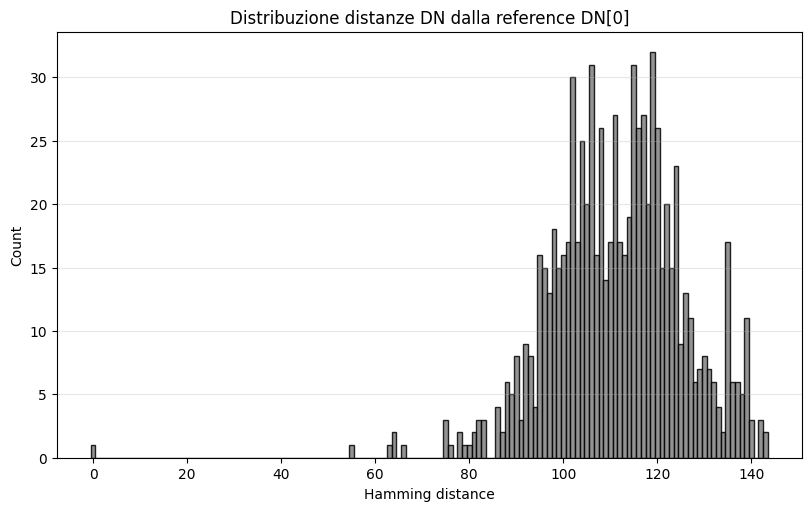

DN size: 817
Min/Max distanza DN dalla reference: 0 / 143
Media distanza DN dalla reference: 111.427


In [30]:
# Istogramma: distanza delle sequenze DN dalla reference (prima sequenza DN)
import matplotlib.pyplot as plt

reference_seq = data_DN[0]
dist_dn_nt = (data_DN != reference_seq).sum(axis=1).astype(np.uint32)

bins = np.arange(0, int(dist_dn_nt.max()) + 2) - 0.5
fig, ax = plt.subplots(1, 1, figsize=(8, 5), constrained_layout=True)
ax.hist(dist_dn_nt, bins=bins, color="gray", alpha=0.85, edgecolor="black")
ax.set_title("Distribuzione distanze DN dalla reference DN[0]")
ax.set_xlabel("Hamming distance")
ax.set_ylabel("Count")
ax.grid(True, axis="y", alpha=0.3)
plt.show()

print(f"DN size: {len(dist_dn_nt)}")
print(f"Min/Max distanza DN dalla reference: {int(dist_dn_nt.min())} / {int(dist_dn_nt.max())}")
print(f"Media distanza DN dalla reference: {float(dist_dn_nt.mean()):.3f}")

## PCA: train su DN (riga 1) vs train su DT-+DT+ (riga 2)
Figura 2x3:
- Colonna 1: scatter delle sole DN
- Colonna 2: spazio one-hot nucleotidico con DN, DT-, DT+
- Colonna 3: spazio X_match (0/1) con DN, DT-, DT+

Riga superiore: PCA allenata su tutte le sequenze DN.
Riga inferiore: PCA allenata sulle sequenze DT- e DT+ unite.

Soglia max DT nucleotide space (diagnostica): 57
Soglia max DT X_match space (diagnostica): 57
PCA one-hot su DN: PC1=0.1075, PC2=0.0680, cum=0.1755
PCA one-hot su DT uniti: PC1=0.1226, PC2=0.0920, cum=0.2146
PCA X_match su DN: PC1=0.1153, PC2=0.0818, cum=0.1971
PCA X_match su DT uniti: PC1=0.1708, PC2=0.0945, cum=0.2653


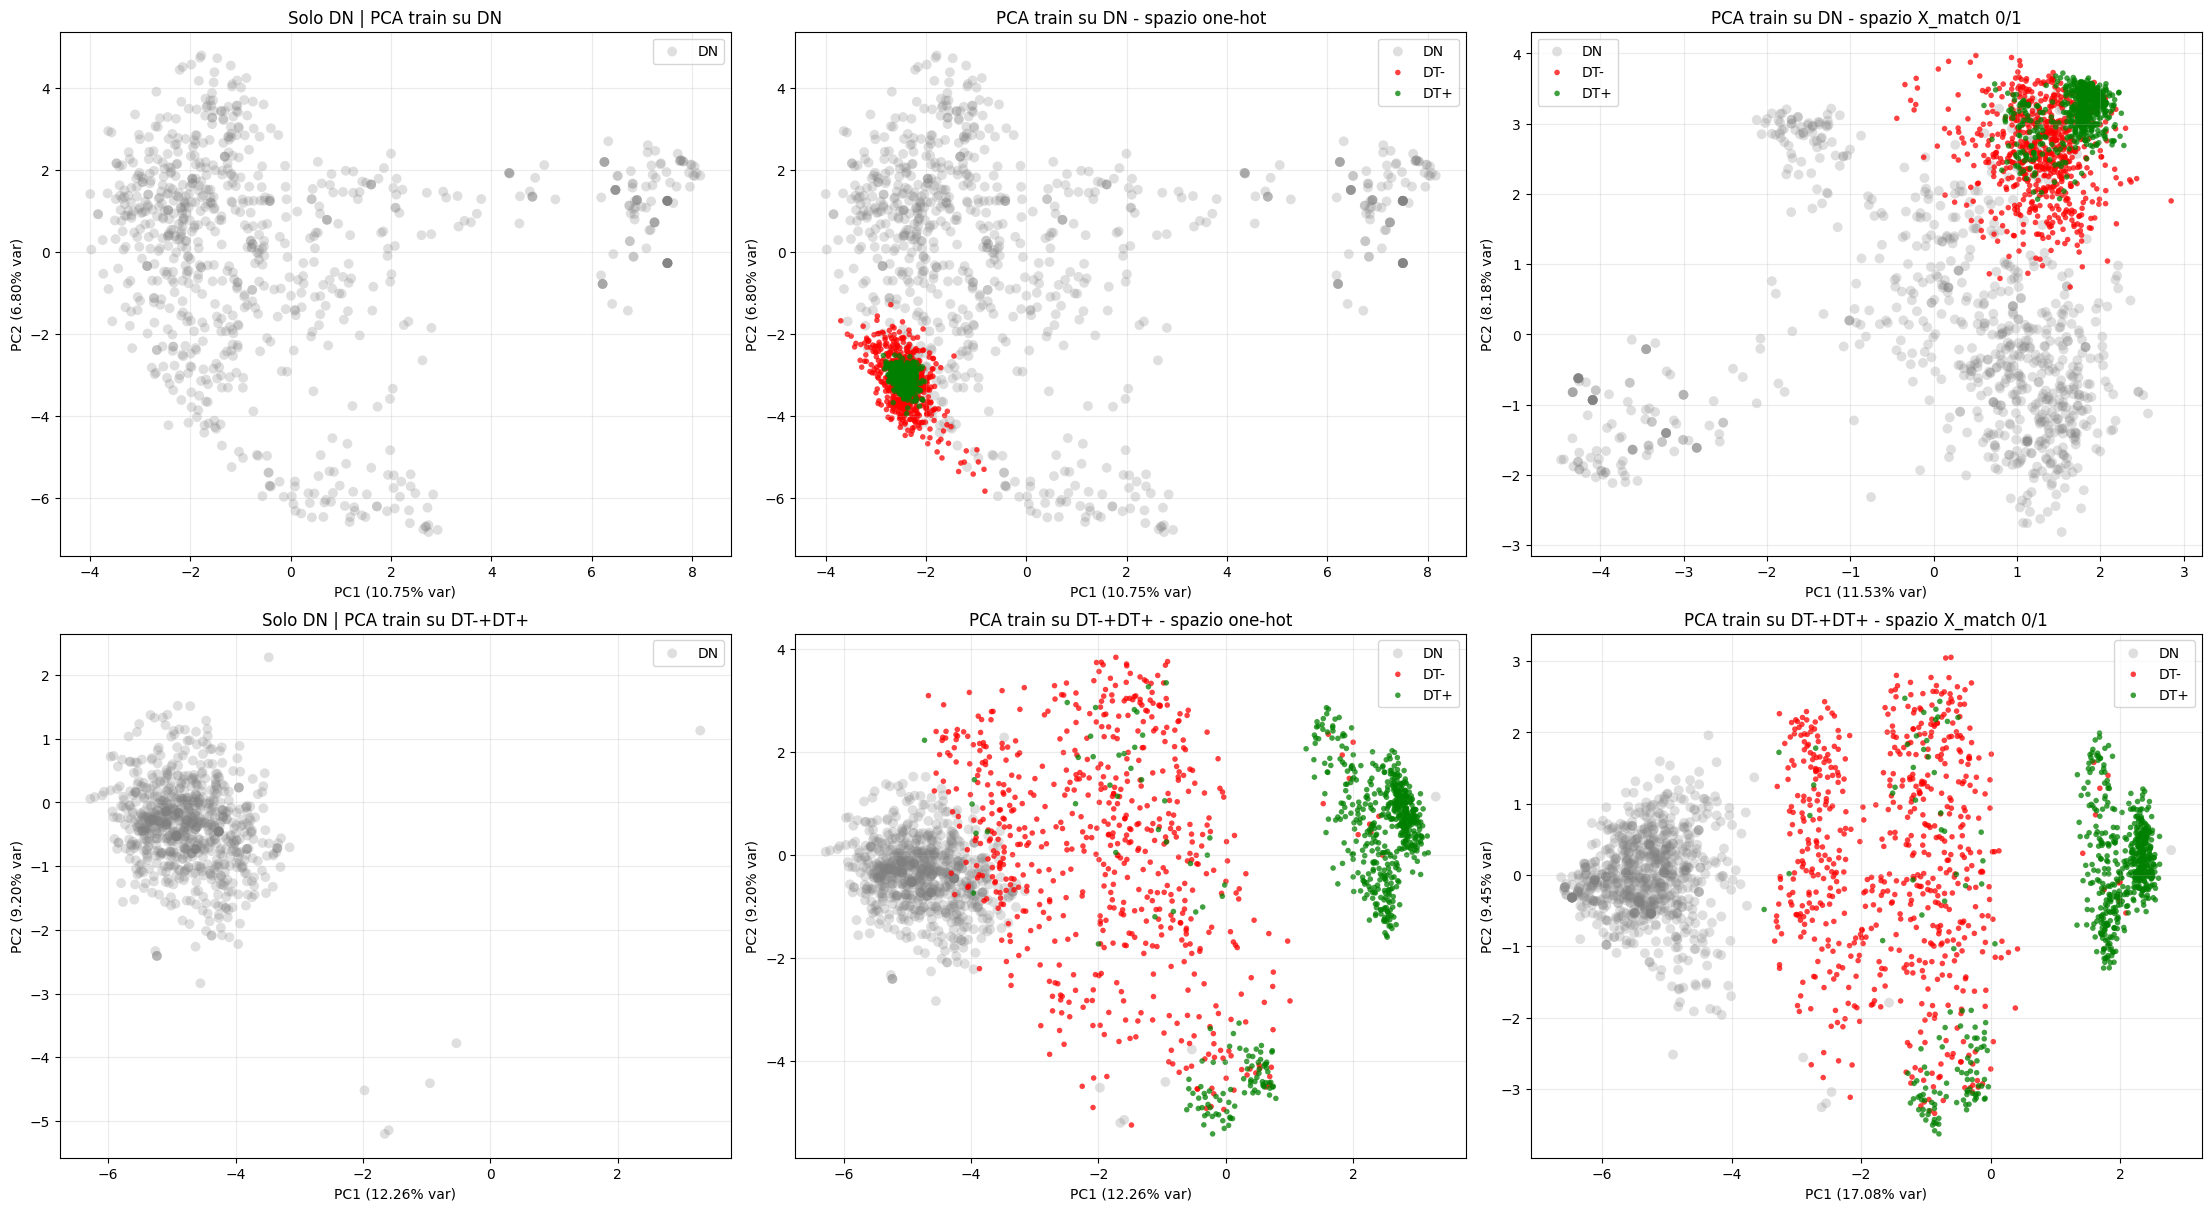

In [31]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

reference_seq = data_DN[0]

# -----------------------------------------------------------------------------
# Costruzione rappresentazioni nei due spazi
# -----------------------------------------------------------------------------
# Spazio nucleotide (one-hot)
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

ohe.fit(data_DN)
X_dn_ohe = ohe.transform(data_DN)
X_dtm_ohe = ohe.transform(data_DTm)
X_dtp_ohe = ohe.transform(data_DTp)
X_dt_ohe = np.concatenate([X_dtm_ohe, X_dtp_ohe], axis=0)

# Spazio X_match (0/1): 1 se uguale alla reference, 0 altrimenti
X_match_dn = (data_DN == reference_seq).astype(np.uint8)
X_match_tm = (data_DTm == reference_seq).astype(np.uint8)
X_match_tp = (data_DTp == reference_seq).astype(np.uint8)
X_match_dt = np.concatenate([X_match_tm, X_match_tp], axis=0)
reference_match = np.ones(reference_seq.shape[0], dtype=np.uint8)

# -----------------------------------------------------------------------------
# Distanze dalla reference e soglie massime su DT (solo diagnostica)
# -----------------------------------------------------------------------------
# Nucleotide space
# (distanza Hamming su sequenze originali)
dist_dn_nt = (data_DN != reference_seq).sum(axis=1).astype(np.uint32)
dist_tm_nt = (data_DTm != reference_seq).sum(axis=1).astype(np.uint32)
dist_tp_nt = (data_DTp != reference_seq).sum(axis=1).astype(np.uint32)
max_dt_nt = int(max(dist_tm_nt.max(), dist_tp_nt.max()))

# X_match space
# (distanza Hamming sui vettori binari)
dist_dn_match = (X_match_dn != reference_match).sum(axis=1).astype(np.uint32)
dist_tm_match = (X_match_tm != reference_match).sum(axis=1).astype(np.uint32)
dist_tp_match = (X_match_tp != reference_match).sum(axis=1).astype(np.uint32)
max_dt_match = int(max(dist_tm_match.max(), dist_tp_match.max()))

print(f"Soglia max DT nucleotide space (diagnostica): {max_dt_nt}")
print(f"Soglia max DT X_match space (diagnostica): {max_dt_match}")

# -----------------------------------------------------------------------------
# PCA NON FILTRATE SU DN (riga alta)
# -----------------------------------------------------------------------------
pca_ohe_full = PCA(n_components=2, random_state=None)
DN_pca_ohe_full = pca_ohe_full.fit_transform(X_dn_ohe)
DTm_pca_ohe_full = pca_ohe_full.transform(X_dtm_ohe)
DTp_pca_ohe_full = pca_ohe_full.transform(X_dtp_ohe)
exp_ohe_full = pca_ohe_full.explained_variance_ratio_

pca_match_full = PCA(n_components=2, random_state=None)
DN_pca_match_full = pca_match_full.fit_transform(X_match_dn)
DTm_pca_match_full = pca_match_full.transform(X_match_tm)
DTp_pca_match_full = pca_match_full.transform(X_match_tp)
exp_match_full = pca_match_full.explained_variance_ratio_

# -----------------------------------------------------------------------------
# PCA SU DT- + DT+ UNITI (riga bassa)
# -----------------------------------------------------------------------------
pca_ohe_dt = PCA(n_components=2, random_state=None)
pca_ohe_dt.fit(X_dt_ohe)
DN_pca_ohe_dt = pca_ohe_dt.transform(X_dn_ohe)
DTm_pca_ohe_dt = pca_ohe_dt.transform(X_dtm_ohe)
DTp_pca_ohe_dt = pca_ohe_dt.transform(X_dtp_ohe)
exp_ohe_dt = pca_ohe_dt.explained_variance_ratio_

pca_match_dt = PCA(n_components=2, random_state=None)
pca_match_dt.fit(X_match_dt)
DN_pca_match_dt = pca_match_dt.transform(X_match_dn)
DTm_pca_match_dt = pca_match_dt.transform(X_match_tm)
DTp_pca_match_dt = pca_match_dt.transform(X_match_tp)
exp_match_dt = pca_match_dt.explained_variance_ratio_

print(
    f"PCA one-hot su DN: PC1={exp_ohe_full[0]:.4f}, PC2={exp_ohe_full[1]:.4f}, cum={exp_ohe_full.sum():.4f}"
)
print(
    f"PCA one-hot su DT uniti: PC1={exp_ohe_dt[0]:.4f}, PC2={exp_ohe_dt[1]:.4f}, cum={exp_ohe_dt.sum():.4f}"
)
print(
    f"PCA X_match su DN: PC1={exp_match_full[0]:.4f}, PC2={exp_match_full[1]:.4f}, cum={exp_match_full.sum():.4f}"
)
print(
    f"PCA X_match su DT uniti: PC1={exp_match_dt[0]:.4f}, PC2={exp_match_dt[1]:.4f}, cum={exp_match_dt.sum():.4f}"
)

# -----------------------------------------------------------------------------
# Figura 2x3:
# colonna 1 = solo DN, colonna 2 = one-hot (DN,DT-,DT+), colonna 3 = X_match (DN,DT-,DT+)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(22, 12), constrained_layout=True)

def plot_dn_only(ax, dn_xy, title, xlabel, ylabel):
    ax.scatter(dn_xy[:, 0], dn_xy[:, 1], c="gray", s=50, alpha=0.25, edgecolor="none", label="DN")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

def plot_three_groups(ax, dn_xy, tm_xy, tp_xy, title, xlabel, ylabel):
    ax.scatter(dn_xy[:, 0], dn_xy[:, 1], c="gray", s=50, alpha=0.25, edgecolor="none", label="DN")
    ax.scatter(tm_xy[:, 0], tm_xy[:, 1], c="red", s=16, alpha=0.75, edgecolor="none", label="DT-")
    ax.scatter(tp_xy[:, 0], tp_xy[:, 1], c="green", s=16, alpha=0.75, edgecolor="none", label="DT+")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

# Riga alta: PCA allenata su DN
plot_dn_only(
    axes[0, 0],
    DN_pca_ohe_full,
    "Solo DN | PCA train su DN",
    f"PC1 ({exp_ohe_full[0] * 100:.2f}% var)",
    f"PC2 ({exp_ohe_full[1] * 100:.2f}% var)",
)

plot_three_groups(
    axes[0, 1],
    DN_pca_ohe_full,
    DTm_pca_ohe_full,
    DTp_pca_ohe_full,
    "PCA train su DN - spazio one-hot",
    f"PC1 ({exp_ohe_full[0] * 100:.2f}% var)",
    f"PC2 ({exp_ohe_full[1] * 100:.2f}% var)",
)

plot_three_groups(
    axes[0, 2],
    DN_pca_match_full,
    DTm_pca_match_full,
    DTp_pca_match_full,
    "PCA train su DN - spazio X_match 0/1",
    f"PC1 ({exp_match_full[0] * 100:.2f}% var)",
    f"PC2 ({exp_match_full[1] * 100:.2f}% var)",
)

# Riga bassa: PCA allenata su DT- + DT+
plot_dn_only(
    axes[1, 0],
    DN_pca_ohe_dt,
    "Solo DN | PCA train su DT-+DT+",
    f"PC1 ({exp_ohe_dt[0] * 100:.2f}% var)",
    f"PC2 ({exp_ohe_dt[1] * 100:.2f}% var)",
)

plot_three_groups(
    axes[1, 1],
    DN_pca_ohe_dt,
    DTm_pca_ohe_dt,
    DTp_pca_ohe_dt,
    "PCA train su DT-+DT+ - spazio one-hot",
    f"PC1 ({exp_ohe_dt[0] * 100:.2f}% var)",
    f"PC2 ({exp_ohe_dt[1] * 100:.2f}% var)",
)

plot_three_groups(
    axes[1, 2],
    DN_pca_match_dt,
    DTm_pca_match_dt,
    DTp_pca_match_dt,
    "PCA train su DT-+DT+ - spazio X_match 0/1",
    f"PC1 ({exp_match_dt[0] * 100:.2f}% var)",
    f"PC2 ({exp_match_dt[1] * 100:.2f}% var)",
)

plt.show()

# Variabili utili per celle successive (mantengo naming precedente)
dn_ohe_encoder = ohe
dn_pca_model = pca_ohe_full
dn_pca_embedding = DN_pca_ohe_full
dtm_pca_projection = DTm_pca_ohe_full
dtp_pca_projection = DTp_pca_ohe_full

dn_match_pca_model = pca_match_full
dn_match_pca_embedding = DN_pca_match_full
dtm_match_pca_projection = DTm_pca_match_full
dtp_match_pca_projection = DTp_pca_match_full

# Oggetti aggiuntivi: confronto train su DN vs train su DT
pca_ohe_full_model = pca_ohe_full
pca_ohe_dt_model = pca_ohe_dt
pca_match_full_model = pca_match_full
pca_match_dt_model = pca_match_dt

max_dt_reference_distance_nt = max_dt_nt
max_dt_reference_distance_xmatch = max_dt_match

Conteggi coppie - nucleotide space:
  Tutte (DT unito): 798216
  Solo DT-       : 203841
  Solo DT+       : 195000
  Tra DT- e DT+  : 399375

Conteggi coppie - binary space:
  Tutte (DT unito): 798216
  Solo DT-       : 203841
  Solo DT+       : 195000
  Tra DT- e DT+  : 399375


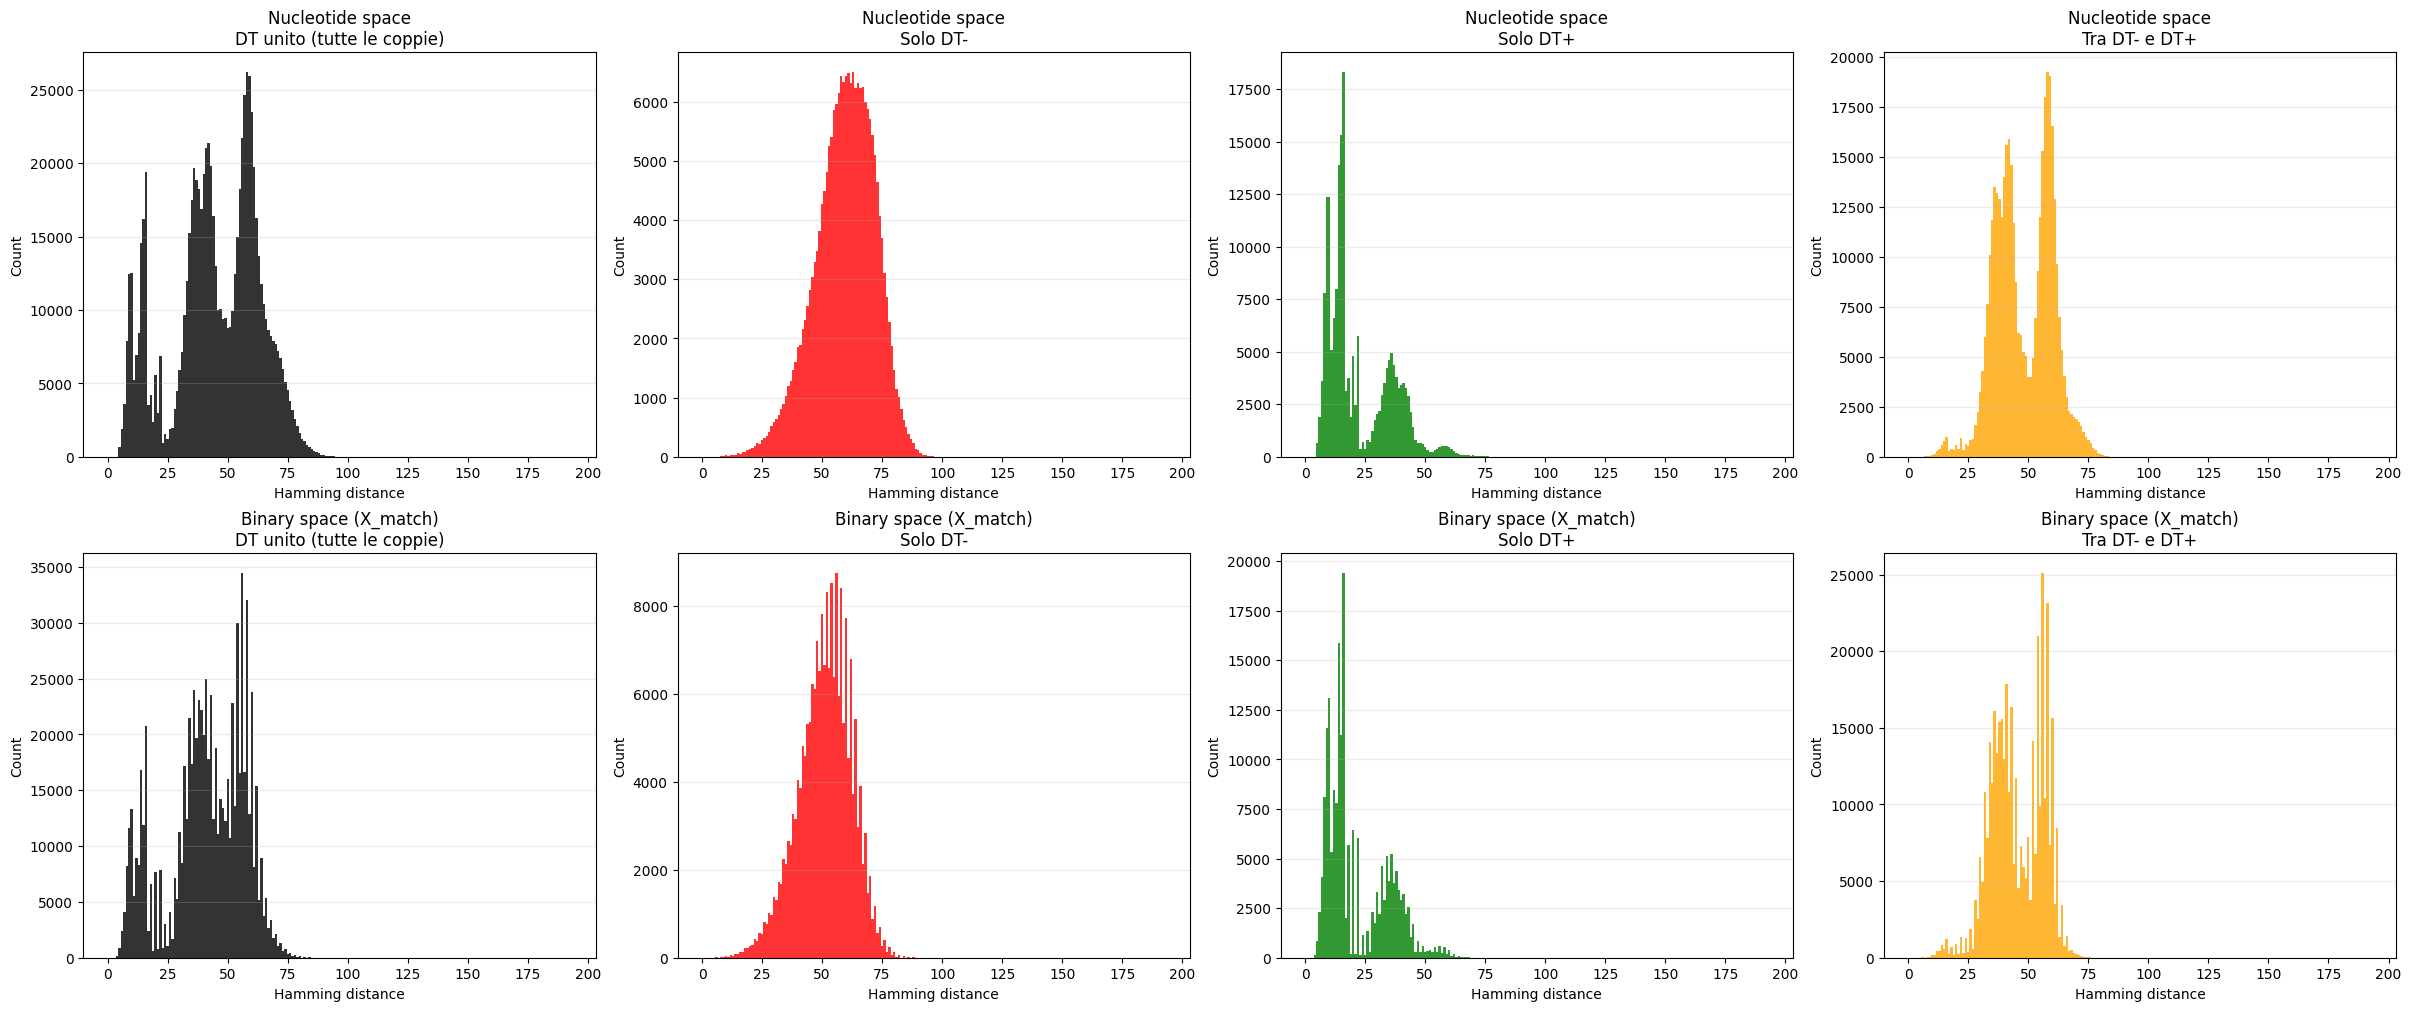

In [32]:
# 2-bis) Distanze pairwise su DT unito in nucleotide e binary space
#       + istogrammi: tutte le coppie, solo DT-, solo DT+, tra DT- e DT+

import matplotlib.pyplot as plt

DTm = data_DTm
DTp = data_DTp
DT_all = np.concatenate([DTm, DTp], axis=0)

reference_seq = data_DN[0]
X_match_tm = (DTm == reference_seq).astype(np.uint8)
X_match_tp = (DTp == reference_seq).astype(np.uint8)
X_match_all = np.concatenate([X_match_tm, X_match_tp], axis=0)

L_nt = DT_all.shape[1]
L_bin = X_match_all.shape[1]


def pairwise_hist_same_set(A: np.ndarray, max_distance: int, chunk_size: int = 128) -> np.ndarray:
    """Istogramma esatto delle distanze per tutte le coppie i<j in A."""
    n = A.shape[0]
    hist = np.zeros(max_distance + 1, dtype=np.int64)

    for i0 in range(0, n, chunk_size):
        i1 = min(i0 + chunk_size, n)
        Ai = A[i0:i1]

        for j0 in range(i0, n, chunk_size):
            j1 = min(j0 + chunk_size, n)
            Aj = A[j0:j1]
            D = (Ai[:, None, :] != Aj[None, :, :]).sum(axis=2)

            if i0 == j0:
                tri = np.triu_indices(i1 - i0, k=1)
                dvals = D[tri]
            else:
                dvals = D.ravel()

            hist += np.bincount(dvals, minlength=max_distance + 1)

    return hist


def pairwise_hist_cross_set(A: np.ndarray, B: np.ndarray, max_distance: int, chunk_size: int = 128) -> np.ndarray:
    """Istogramma esatto delle distanze per tutte le coppie tra A e B."""
    n = A.shape[0]
    hist = np.zeros(max_distance + 1, dtype=np.int64)

    for i0 in range(0, n, chunk_size):
        i1 = min(i0 + chunk_size, n)
        Ai = A[i0:i1]
        D = (Ai[:, None, :] != B[None, :, :]).sum(axis=2)
        hist += np.bincount(D.ravel(), minlength=max_distance + 1)

    return hist


# Nucleotide space
hist_all_nt = pairwise_hist_same_set(DT_all, max_distance=L_nt, chunk_size=128)
hist_tm_nt = pairwise_hist_same_set(DTm, max_distance=L_nt, chunk_size=128)
hist_tp_nt = pairwise_hist_same_set(DTp, max_distance=L_nt, chunk_size=128)
hist_tm_tp_nt = pairwise_hist_cross_set(DTm, DTp, max_distance=L_nt, chunk_size=128)

# Binary space
hist_all_bin = pairwise_hist_same_set(X_match_all, max_distance=L_bin, chunk_size=128)
hist_tm_bin = pairwise_hist_same_set(X_match_tm, max_distance=L_bin, chunk_size=128)
hist_tp_bin = pairwise_hist_same_set(X_match_tp, max_distance=L_bin, chunk_size=128)
hist_tm_tp_bin = pairwise_hist_cross_set(X_match_tm, X_match_tp, max_distance=L_bin, chunk_size=128)

print("Conteggi coppie - nucleotide space:")
print(f"  Tutte (DT unito): {hist_all_nt.sum()}")
print(f"  Solo DT-       : {hist_tm_nt.sum()}")
print(f"  Solo DT+       : {hist_tp_nt.sum()}")
print(f"  Tra DT- e DT+  : {hist_tm_tp_nt.sum()}")

print("\nConteggi coppie - binary space:")
print(f"  Tutte (DT unito): {hist_all_bin.sum()}")
print(f"  Solo DT-       : {hist_tm_bin.sum()}")
print(f"  Solo DT+       : {hist_tp_bin.sum()}")
print(f"  Tra DT- e DT+  : {hist_tm_tp_bin.sum()}")

# Plot: 2 righe (nucleotide / binary) x 4 colonne (all / DT- / DT+ / cross)
fig, axes = plt.subplots(2, 4, figsize=(24, 10), constrained_layout=True)

x_nt = np.arange(L_nt + 1)
x_bin = np.arange(L_bin + 1)

spec_nt = [
    (hist_all_nt, "DT unito (tutte le coppie)", "black"),
    (hist_tm_nt, "Solo DT-", "red"),
    (hist_tp_nt, "Solo DT+", "green"),
    (hist_tm_tp_nt, "Tra DT- e DT+", "orange"),
]
spec_bin = [
    (hist_all_bin, "DT unito (tutte le coppie)", "black"),
    (hist_tm_bin, "Solo DT-", "red"),
    (hist_tp_bin, "Solo DT+", "green"),
    (hist_tm_tp_bin, "Tra DT- e DT+", "orange"),
]

for j, (hist_j, title_j, color_j) in enumerate(spec_nt):
    ax = axes[0, j]
    ax.bar(x_nt, hist_j, color=color_j, alpha=0.8, width=1.0)
    ax.set_title(f"Nucleotide space\n{title_j}")
    ax.set_xlabel("Hamming distance")
    ax.set_ylabel("Count")
    ax.grid(True, axis="y", alpha=0.25)

for j, (hist_j, title_j, color_j) in enumerate(spec_bin):
    ax = axes[1, j]
    ax.bar(x_bin, hist_j, color=color_j, alpha=0.8, width=1.0)
    ax.set_title(f"Binary space (X_match)\n{title_j}")
    ax.set_xlabel("Hamming distance")
    ax.set_ylabel("Count")
    ax.grid(True, axis="y", alpha=0.25)

plt.show()

# Variabili utili per downstream
pairwise_histograms = {
    "nucleotide": {
        "all": hist_all_nt,
        "dtm": hist_tm_nt,
        "dtp": hist_tp_nt,
        "dtm_vs_dtp": hist_tm_tp_nt,
    },
    "binary": {
        "all": hist_all_bin,
        "dtm": hist_tm_bin,
        "dtp": hist_tp_bin,
        "dtm_vs_dtp": hist_tm_tp_bin,
    },
}

## 8) Clustering Methods su DT- e DT+ (spazio nucleotidi + spazio binario)
In questa sezione proviamo due metodi per associare sequenze DT+ a sequenze DT-:
1. **Top-N nearest neighbors**: per ogni DT+ prendiamo le prime N DT- piu vicine.
2. **KMeans con best-k**: clusterizziamo DT- e DT+ insieme, scegliamo k via silhouette,
   poi per ogni DT+ prendiamo tutte le DT- nello stesso cluster.

I risultati vengono salvati in CSV (una riga per ogni DT+).

Running KMeans for k=4...
Running KMeans for k=5...
Running KMeans for k=6...
Running KMeans for k=7...
Running KMeans for k=8...
Running KMeans for k=9...
Running KMeans for k=10...


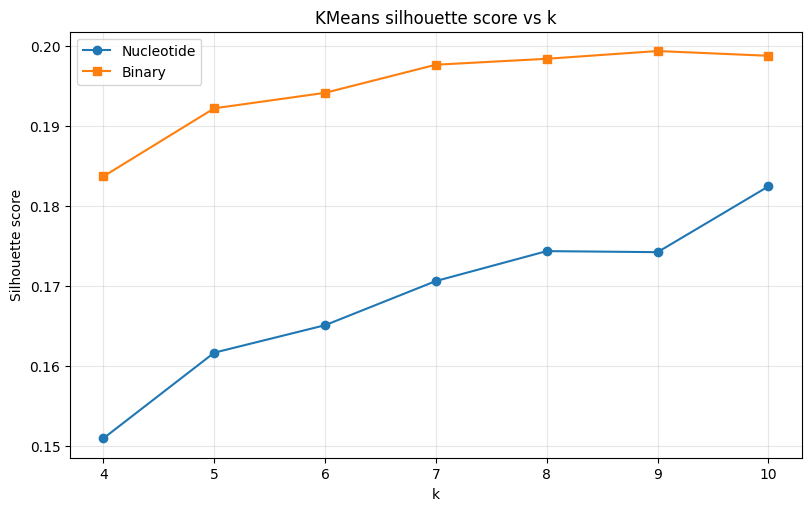

CSV salvati (Top-N):
Group_I_intron-2/Experiment_Results/clustering_methods/vae_split/outside_25_30/top5_nt.csv
Group_I_intron-2/Experiment_Results/clustering_methods/vae_split/outside_25_30/top5_bin.csv
Group_I_intron-2/Experiment_Results/clustering_methods/vae_split/outside_25_30/top10_nt.csv
Group_I_intron-2/Experiment_Results/clustering_methods/vae_split/outside_25_30/top10_bin.csv
Group_I_intron-2/Experiment_Results/clustering_methods/vae_split/outside_25_30/top15_nt.csv
Group_I_intron-2/Experiment_Results/clustering_methods/vae_split/outside_25_30/top15_bin.csv
Group_I_intron-2/Experiment_Results/clustering_methods/vae_split/outside_25_30/top20_nt.csv
Group_I_intron-2/Experiment_Results/clustering_methods/vae_split/outside_25_30/top20_bin.csv

CSV salvati (KMeans, k=4..10):
Group_I_intron-2/Experiment_Results/clustering_methods/vae_split/outside_25_30/km_nt_k4.csv
Group_I_intron-2/Experiment_Results/clustering_methods/vae_split/outside_25_30/km_bin_k4.csv
Group_I_intron-2/Experim

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder

# -----------------------------------------------------------------------------
# Parametri configurabili
# -----------------------------------------------------------------------------
neighbor_values = [5, 10, 15, 20]
k_values = list(range(4, 11))  # 4..10 inclusi
silhouette_sample_size = 3000
random_seed = None #42

# Parametri KMeans piu leggeri per completare in tempi brevi
kmeans_n_init = 15
kmeans_max_iter = 500

# -----------------------------------------------------------------------------
# Utility: CSV senza header, una riga per DT+, solo indici DT- separati da virgole
# -----------------------------------------------------------------------------
def write_index_rows_csv(path: Path, rows) -> None:
    with path.open("w", encoding="utf-8") as f:
        for arr in rows:
            vals = np.asarray(arr, dtype=int).tolist()
            f.write(",".join(map(str, vals)) + "\n")


# -----------------------------------------------------------------------------
# Dataset DT- / DT+
# -----------------------------------------------------------------------------
DTm = data_DTm
DTp = data_DTp
n_tm = DTm.shape[0]
n_tp = DTp.shape[0]

reference_seq = data_DN[0]
X_match_tm = (DTm == reference_seq).astype(np.uint8)
X_match_tp = (DTp == reference_seq).astype(np.uint8)

# -----------------------------------------------------------------------------
# Metodo 1: Top-N nearest neighbors (spazio nucleotidi)
#           Salva 4 CSV distinti per N in neighbor_values
# -----------------------------------------------------------------------------
if any((n <= 0 or n > n_tm) for n in neighbor_values):
    raise ValueError(f"Valori non validi in neighbor_values={neighbor_values} rispetto a #DT-={n_tm}")

D_tp_tm_nt = pairwise_hamming_chunked(DTp, DTm, chunk_size=256)
D_tp_tm_bin = pairwise_hamming_chunked(X_match_tp, X_match_tm, chunk_size=256)

topn_paths_nt = {}
topn_paths_bin = {}

for n_neighbors in neighbor_values:
    nearest_idx_nt = topk_smallest_indices(D_tp_tm_nt, k=n_neighbors)
    rows_topn_nt = [nearest_idx_nt[i] for i in range(n_tp)]
    path_topn_nt = OUTPUT_CLUSTER_DIR / FILE_TOPN_NT_PATTERN.format(n=n_neighbors)
    write_index_rows_csv(path_topn_nt, rows_topn_nt)
    topn_paths_nt[n_neighbors] = path_topn_nt

    nearest_idx_bin = topk_smallest_indices(D_tp_tm_bin, k=n_neighbors)
    rows_topn_bin = [nearest_idx_bin[i] for i in range(n_tp)]
    path_topn_bin = OUTPUT_CLUSTER_DIR / FILE_TOPN_BIN_PATTERN.format(n=n_neighbors)
    write_index_rows_csv(path_topn_bin, rows_topn_bin)
    topn_paths_bin[n_neighbors] = path_topn_bin

# -----------------------------------------------------------------------------
# Metodo 2: KMeans per k=4..10 (spazio nucleotidi one-hot)
#           Per ogni DT+ salva tutti gli indici DT- nello stesso cluster
# -----------------------------------------------------------------------------
DT_all = np.concatenate([DTm, DTp], axis=0)

try:
    ohe_dt = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe_dt = OneHotEncoder(handle_unknown="ignore", sparse=False)

X_nt_all = ohe_dt.fit_transform(DT_all).astype(np.float32)
X_bin_all = np.concatenate([X_match_tm, X_match_tp], axis=0).astype(np.float32)

sil_scores_nt = []
sil_scores_bin = []

for k in k_values:
    print(f"Running KMeans for k={k}...")

    # Nucleotide space
    km_nt = KMeans(
        n_clusters=k,
        n_init=kmeans_n_init,
        max_iter=kmeans_max_iter,
        algorithm="elkan",
        random_state=random_seed,
    )
    labels_nt = km_nt.fit_predict(X_nt_all)
    sil_nt = silhouette_score(
        X_nt_all,
        labels_nt,
        sample_size=min(silhouette_sample_size, X_nt_all.shape[0]),
        random_state=random_seed,
    )
    sil_scores_nt.append(sil_nt)

    labels_tm_nt = labels_nt[:n_tm]
    labels_tp_nt = labels_nt[n_tm:]
    rows_k_nt = []
    for i in range(n_tp):
        c = labels_tp_nt[i]
        idx_same_cluster = np.where(labels_tm_nt == c)[0]
        rows_k_nt.append(idx_same_cluster)

    path_kmeans_nt = OUTPUT_CLUSTER_DIR / FILE_KMEANS_NT_PATTERN.format(k=k)
    write_index_rows_csv(path_kmeans_nt, rows_k_nt)

    # Binary space
    km_bin = KMeans(
        n_clusters=k,
        n_init=kmeans_n_init,
        max_iter=kmeans_max_iter,
        algorithm="elkan",
        random_state=random_seed,
    )
    labels_bin = km_bin.fit_predict(X_bin_all)
    sil_bin = silhouette_score(
        X_bin_all,
        labels_bin,
        sample_size=min(silhouette_sample_size, X_bin_all.shape[0]),
        random_state=random_seed,
    )
    sil_scores_bin.append(sil_bin)

    labels_tm_bin = labels_bin[:n_tm]
    labels_tp_bin = labels_bin[n_tm:]
    rows_k_bin = []
    for i in range(n_tp):
        c = labels_tp_bin[i]
        idx_same_cluster = np.where(labels_tm_bin == c)[0]
        rows_k_bin.append(idx_same_cluster)

    path_kmeans_bin = OUTPUT_CLUSTER_DIR / FILE_KMEANS_BIN_PATTERN.format(k=k)
    write_index_rows_csv(path_kmeans_bin, rows_k_bin)

# -----------------------------------------------------------------------------
# Grafico silhouette score (solo per KMeans)
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(8, 5), constrained_layout=True)
ax.plot(k_values, sil_scores_nt, marker="o", color="tab:blue", label="Nucleotide")
ax.plot(k_values, sil_scores_bin, marker="s", color="tab:orange", label="Binary")
ax.set_title("KMeans silhouette score vs k")
ax.set_xlabel("k")
ax.set_ylabel("Silhouette score")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()

print("CSV salvati (Top-N):")
for n_neighbors in neighbor_values:
    print(topn_paths_nt[n_neighbors])
    print(topn_paths_bin[n_neighbors])

print("\nCSV salvati (KMeans, k=4..10):")
for k in k_values:
    print(OUTPUT_CLUSTER_DIR / FILE_KMEANS_NT_PATTERN.format(k=k))
    print(OUTPUT_CLUSTER_DIR / FILE_KMEANS_BIN_PATTERN.format(k=k))

print("\nSilhouette KMeans:")
for k, s_nt, s_bin in zip(k_values, sil_scores_nt, sil_scores_bin):
    print(f"k={k}: nucleotide={s_nt:.4f}, binary={s_bin:.4f}")

# Export variabili utili
topn_neighbors_values = neighbor_values
topn_csv_paths_nucleotide = topn_paths_nt
topn_csv_paths_binary = topn_paths_bin
kmeans_k_values_tested = k_values
kmeans_silhouette_nucleotide = sil_scores_nt
kmeans_silhouette_binary = sil_scores_bin

In [34]:
# # 2) Hamming distance tra ogni sequenza DT- con tutte le DT- e tutte le DT+
# D_hamm_tm_tm = pairwise_hamming_chunked(data_DTm, data_DTm, chunk_size=256)
# D_hamm_tm_tp = pairwise_hamming_chunked(data_DTm, data_DTp, chunk_size=256)

# print("D_hamm_tm_tm shape:", D_hamm_tm_tm.shape)
# print("D_hamm_tm_tp shape:", D_hamm_tm_tp.shape)
# print("Range D_hamm_tm_tm:", int(D_hamm_tm_tm.min()), int(D_hamm_tm_tm.max()))
# print("Range D_hamm_tm_tp:", int(D_hamm_tm_tp.min()), int(D_hamm_tm_tp.max()))

In [35]:
# # 3) Trasformazione in vettori binari rispetto alla prima sequenza di DN
# # 1 se uguale alla reference in posizione i, 0 altrimenti
# reference_seq = data_DN[0]

# X_match_tm = (data_DTm == reference_seq).astype(np.uint8)
# X_match_tp = (data_DTp == reference_seq).astype(np.uint8)
# reference_match = np.ones(reference_seq.shape[0], dtype=np.uint8)

# print("X_match_tm shape:", X_match_tm.shape)
# print("X_match_tp shape:", X_match_tp.shape)

In [36]:
# # 4) Distanze Hamming tra i vettori binari (stesso schema del punto 2)
# D_bin_tm_tm = pairwise_hamming_chunked(X_match_tm, X_match_tm, chunk_size=256)
# D_bin_tm_tp = pairwise_hamming_chunked(X_match_tm, X_match_tp, chunk_size=256)

# print("D_bin_tm_tm shape:", D_bin_tm_tm.shape)
# print("D_bin_tm_tp shape:", D_bin_tm_tp.shape)
# print("Range D_bin_tm_tm:", int(D_bin_tm_tm.min()), int(D_bin_tm_tm.max()))
# print("Range D_bin_tm_tp:", int(D_bin_tm_tp.min()), int(D_bin_tm_tp.max()))

In [37]:
# # 5) Distanza di ogni sequenza DT- e DT+ dalla prima sequenza DN
# # Metrica 1: Hamming su nucleotidi
# dist_ref_tm_hamm = (data_DTm != reference_seq).sum(axis=1).astype(np.uint32)
# dist_ref_tp_hamm = (data_DTp != reference_seq).sum(axis=1).astype(np.uint32)

# # Metrica 2: Hamming nel vettore binario di match
# dist_ref_tm_bin = (X_match_tm != reference_match).sum(axis=1).astype(np.uint32)
# dist_ref_tp_bin = (X_match_tp != reference_match).sum(axis=1).astype(np.uint32)

# print("Media distanza ref DT- (hamming nucleotidi):", float(dist_ref_tm_hamm.mean()))
# print("Media distanza ref DT+ (hamming nucleotidi):", float(dist_ref_tp_hamm.mean()))
# print("Media distanza ref DT- (binario):", float(dist_ref_tm_bin.mean()))
# print("Media distanza ref DT+ (binario):", float(dist_ref_tp_bin.mean()))

# df_ref_dist = pd.DataFrame({
#     "dataset": ["DT-"] * len(dist_ref_tm_hamm) + ["DT+"] * len(dist_ref_tp_hamm),
#     "seq_index_in_dataset": list(range(len(dist_ref_tm_hamm))) + list(range(len(dist_ref_tp_hamm))),
#     "dist_ref_hamming_nt": np.concatenate([dist_ref_tm_hamm, dist_ref_tp_hamm]),
#     "dist_ref_hamming_bin": np.concatenate([dist_ref_tm_bin, dist_ref_tp_bin]),
# })

# ref_csv_path = OUTPUT_ROOT_DIR / FILE_REF_DIST
# df_ref_dist.to_csv(ref_csv_path, index=False)
# print(f"Salvato: {ref_csv_path}")

In [38]:
# # 6) Per ogni sequenza DT+ trova le 10 piu vicine in DT- per entrambe le metriche
# # Per avere DT+ come righe, calcoliamo esplicitamente DT+ vs DT-
# D_hamm_tp_tm = pairwise_hamming_chunked(data_DTp, data_DTm, chunk_size=256)
# D_bin_tp_tm = pairwise_hamming_chunked(X_match_tp, X_match_tm, chunk_size=256)

# k = 10
# nearest_tm_idx_hamm = topk_smallest_indices(D_hamm_tp_tm, k=k)
# nearest_tm_idx_bin = topk_smallest_indices(D_bin_tp_tm, k=k)

# print("Nearest index matrix (hamming nucleotidi):", nearest_tm_idx_hamm.shape)
# print("Nearest index matrix (binario):", nearest_tm_idx_bin.shape)

In [39]:
# # 7) CSV finale con 10 colonne di indici DT-
# # Riga i = sequenza DT+[i], colonne = indici delle 10 DT- piu vicine
# columns = [f"nn_{i+1}" for i in range(10)]

# df_nn_hamm = pd.DataFrame(nearest_tm_idx_hamm, columns=columns)
# df_nn_bin = pd.DataFrame(nearest_tm_idx_bin, columns=columns)

# csv_hamm_path = OUTPUT_ROOT_DIR / FILE_TOP10_NT
# csv_bin_path = OUTPUT_ROOT_DIR / FILE_TOP10_BIN

# df_nn_hamm.to_csv(csv_hamm_path, index=False)
# df_nn_bin.to_csv(csv_bin_path, index=False)

# print(f"Salvato: {csv_hamm_path}")
# print(f"Salvato: {csv_bin_path}")

# display(df_nn_hamm.head())
# display(df_nn_bin.head())